In [1]:
"""
==========================================================
Exploratory Data Analysis (EDA)

Project:
Client Trading Propensity Prediction

Author:
Priyansh Mahajan

Description
-----------
Performs complete exploratory data analysis on the
synthetic brokerage customer dataset.

Outputs:
---------
outputs/
    age_distribution.png
    target_distribution.png
    correlation_heatmap.png
    feature_vs_target.png
    categorical_target_rate.png
    eda_dataset.csv
==========================================================
"""

'\n==========================================================\nExploratory Data Analysis (EDA)\n\nProject:\nClient Trading Propensity Prediction\n\nAuthor:\nPriyansh Mahajan\n\nDescription\n-----------\nPerforms complete exploratory data analysis on the\nsynthetic brokerage customer dataset.\n\nOutputs:\n---------\noutputs/\n    age_distribution.png\n    target_distribution.png\n    correlation_heatmap.png\n    feature_vs_target.png\n    categorical_target_rate.png\n    eda_dataset.csv\n==========================================================\n'

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

In [3]:
# ----------------------------------------------------------
# Configuration
# ----------------------------------------------------------
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"

In [ ]:
RAW_DATA = DATA_DIR / "customer_propensity_dummy_data.csv"

OUTPUT_DATA = OUTPUT_DIR / "eda_dataset.csv"

FIGURE_PATH = OUTPUT_DIR

os.makedirs(FIGURE_PATH, exist_ok=True)

sns.set_style("whitegrid")

In [104]:
# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------
print("=" * 70)
print("Loading Dataset")
print("=" * 70)

df = pd.read_csv(RAW_DATA)

df.head()

Loading Dataset


,Client_Code,current_age,entry_age,vintage_months,DP_Value,Total_Margin,ord_cash,ord_derv,ord_comm,ord_curr,Category_Bucket_final,Vertical,self_dealer_status,Number_of_competition_account,plan,Dealing_Zone,MTF_taken,recency,target
0,C10000000,46,46,91,0.00,8.97,3,0,0,0,6. Base,Online,100% Self,0,Free Plan,West,0,2807.0,0
1,C10000001,37,33,45,6848.11,0.00,2,3,0,0,6. Base,Bank,Missing,0,Others,West,0,NaN,0
2,C10000002,48,46,65,0.00,0.00,2,1,0,0,6. Base,Bank,Missing,2,Youth,North,0,NaN,0
3,C10000003,61,38,20,3207.79,0.00,2,0,0,0,6. Base,Online,100% Self,0,Others,South,0,NaN,0
4,C10000004,36,33,95,0.00,0.00,2,1,0,0,6. Base,Online,<25% Self,0,Free Plan,West,0,NaN,0


In [105]:
# ----------------------------------------------------------
# Dataset Overview
# ----------------------------------------------------------

In [106]:
print("=" * 70)
print("Dataset Shape")
print("=" * 70)

df.shape

Dataset Shape


(500000, 19)

In [107]:
print("=" * 70)
print("Column Types")
print("=" * 70)

df.dtypes

Column Types


Client_Code                       object
current_age                        int64
entry_age                          int64
vintage_months                     int64
DP_Value                         float64
Total_Margin                     float64
ord_cash                           int64
ord_derv                           int64
ord_comm                           int64
ord_curr                           int64
Category_Bucket_final             object
Vertical                          object
self_dealer_status                object
Number_of_competition_account      int64
plan                              object
Dealing_Zone                      object
MTF_taken                          int64
recency                          float64
target                             int64
dtype: object

In [108]:
print("=" * 70)
print("Missing Values")
print("=" * 70)

df.isnull().sum()

Missing Values


Client_Code                           0
current_age                           0
entry_age                             0
vintage_months                        0
DP_Value                              0
Total_Margin                          0
ord_cash                              0
ord_derv                              0
ord_comm                              0
ord_curr                              0
Category_Bucket_final                 0
Vertical                              0
self_dealer_status                    0
Number_of_competition_account         0
plan                                  0
Dealing_Zone                          0
MTF_taken                             0
recency                          219948
target                                0
dtype: int64

In [109]:
print("=" * 70)
print("Target Distribution")
print("=" * 70)

df["target"].value_counts(normalize=True)

Target Distribution


target
0    0.99227
1    0.00773
Name: proportion, dtype: float64

In [110]:
# ----------------------------------------------------------
# Numerical Summary
# ----------------------------------------------------------

In [111]:
numerical_cols = [

    "current_age",
    "entry_age",
    "vintage_months",
    "DP_Value",
    "Total_Margin",
    "ord_cash",
    "ord_derv",
    "ord_comm",
    "ord_curr",
    "recency",
    "MTF_taken",
    "Number_of_competition_account"

]

In [112]:
print("=" * 70)
print("Numerical Summary")
print("=" * 70)

df[numerical_cols].describe()

Numerical Summary


,current_age,entry_age,vintage_months,DP_Value,Total_Margin,ord_cash,ord_derv,ord_comm,ord_curr,recency,MTF_taken,Number_of_competition_account
count,500000.000000,500000.000000,500000.000000,5.000000e+05,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000,280052.000000,500000.000000,500000.000000
mean,39.460814,29.929402,76.251426,2.394960e+03,1.367629e+03,9.890208,4.523248,0.059550,0.019866,2219.036900,0.016158,9.478140
std,13.576882,12.287905,49.329275,3.122139e+04,2.079362e+04,33.442522,26.647324,0.241818,0.140183,1250.591659,0.126083,13.939811
min,18.000000,18.000000,11.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,56.000000,0.000000,0.000000
25%,29.000000,18.000000,40.000000,0.000000e+00,0.000000e+00,2.000000,0.000000,0.000000,0.000000,1135.000000,0.000000,0.000000
50%,39.000000,27.000000,66.000000,0.000000e+00,0.000000e+00,3.000000,1.000000,0.000000,0.000000,2216.000000,0.000000,2.000000
75%,49.000000,38.000000,101.000000,1.576125e+02,3.076825e+02,4.000000,2.000000,0.000000,0.000000,3302.000000,0.000000,16.000000
max,85.000000,85.000000,359.000000,1.389001e+07,1.209539e+07,257.000000,303.000000,3.000000,2.000000,4383.000000,1.000000,47.000000


In [113]:
# ----------------------------------------------------------
# Categorical Summary
# ----------------------------------------------------------

In [114]:
categorical_cols = [

    "Category_Bucket_final",
    "Vertical",
    "self_dealer_status",
    "plan"

]

In [115]:
for col in categorical_cols:

    print("\n")
    print("=" * 70)
    print(col)
    print("=" * 70)

    print(df[col].value_counts())



Category_Bucket_final
Category_Bucket_final
6. Base        492675
5. Standard      3446
4. Bronze        1425
2. Gold           982
3. Silver         967
1. Platinum       505
Name: count, dtype: int64


Vertical
Vertical
Online        400404
Bank           30080
Franchisee     29782
Branch         29695
HVC            10039
Name: count, dtype: int64


self_dealer_status
self_dealer_status
Missing        260020
100% Self      139972
100% Dealer     49647
>75% Self       20150
26-50% Self     12577
51-75% Self     10141
<25% Self        7493
Name: count, dtype: int64


plan
plan
Free Plan    239914
Others       185127
Youth         69901
Pro            4567
Max             491
Name: count, dtype: int64


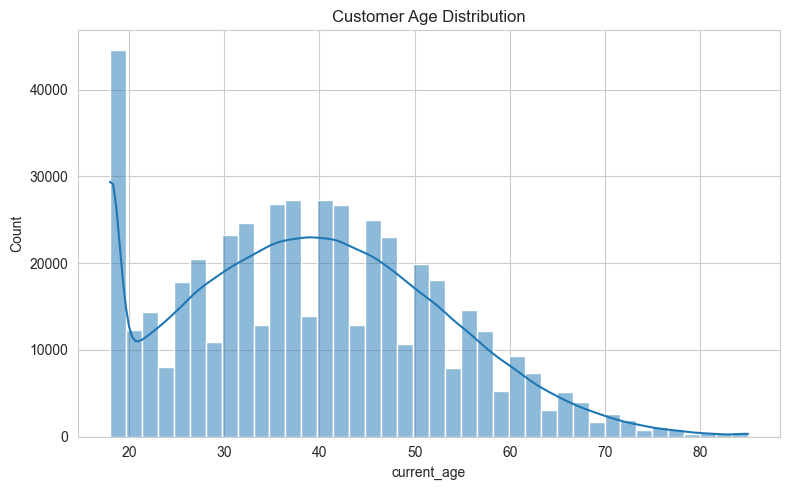

In [116]:
# ----------------------------------------------------------
# Age Distribution
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    df["current_age"],
    bins=40,
    kde=True
)

plt.title("Customer Age Distribution")

plt.tight_layout()

plt.show()

plt.savefig(f"{FIGURE_PATH}/age_distribution.png")

plt.close()

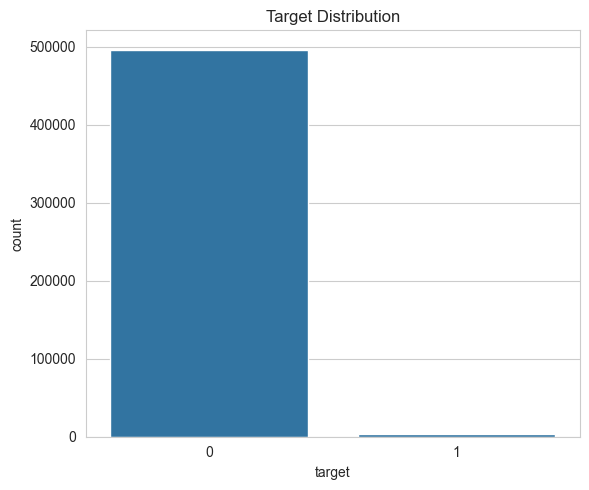

In [117]:
# ----------------------------------------------------------
# Target Distribution
# ----------------------------------------------------------

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Target Distribution")

plt.tight_layout()

plt.show()

plt.savefig(f"{FIGURE_PATH}/target_distribution.png")

plt.close()

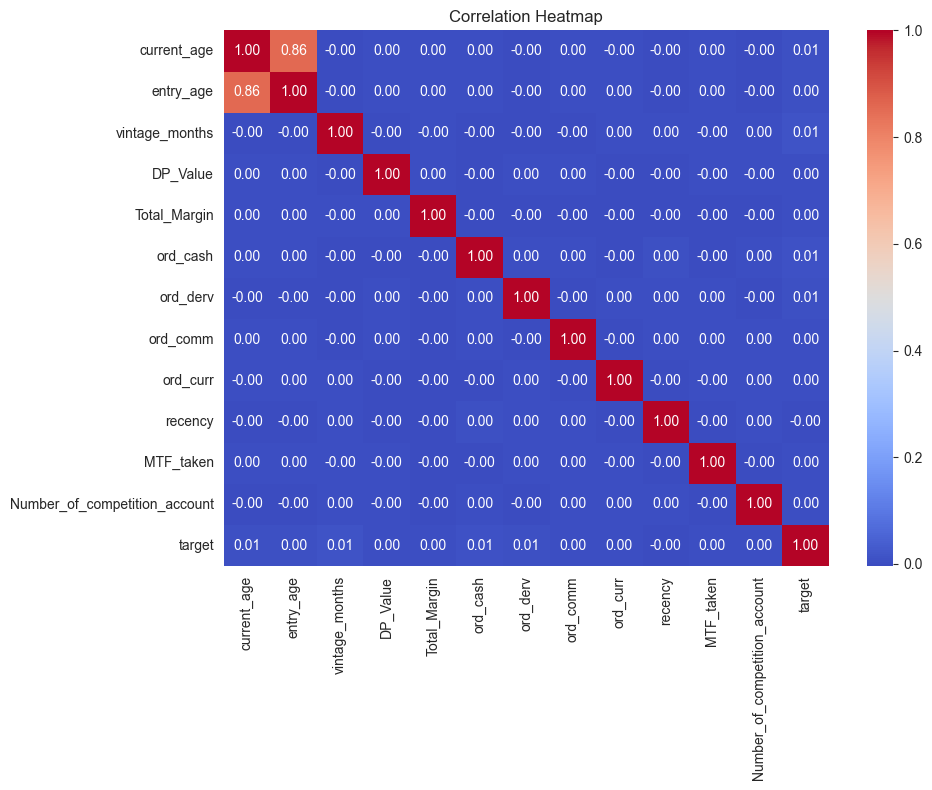

In [118]:
# ----------------------------------------------------------
# Correlation Heatmap
# ----------------------------------------------------------

plt.figure(figsize=(10,8))

corr = df[numerical_cols + ["target"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

plt.savefig(f"{FIGURE_PATH}/correlation_heatmap.png")

plt.close()

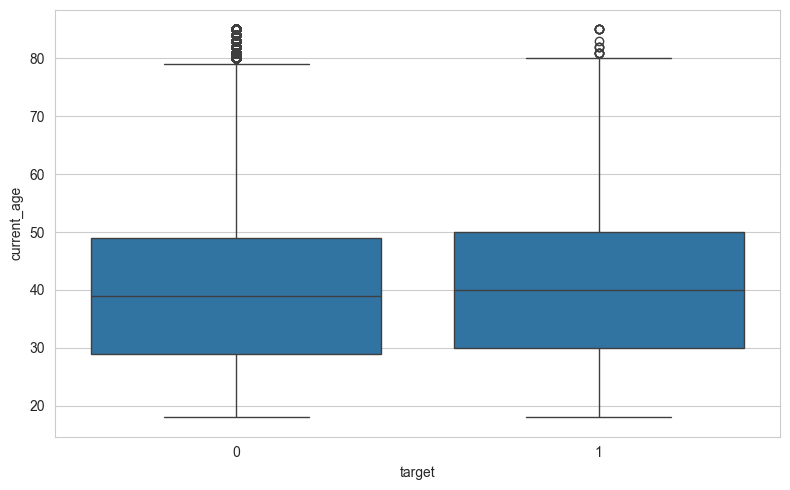

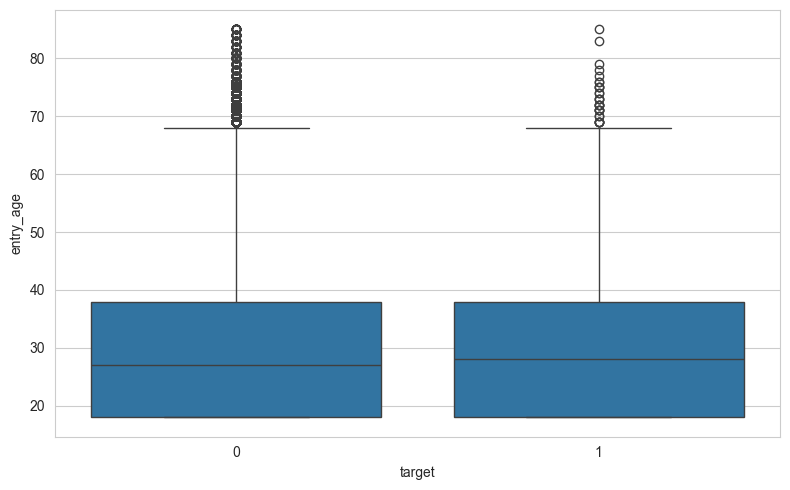

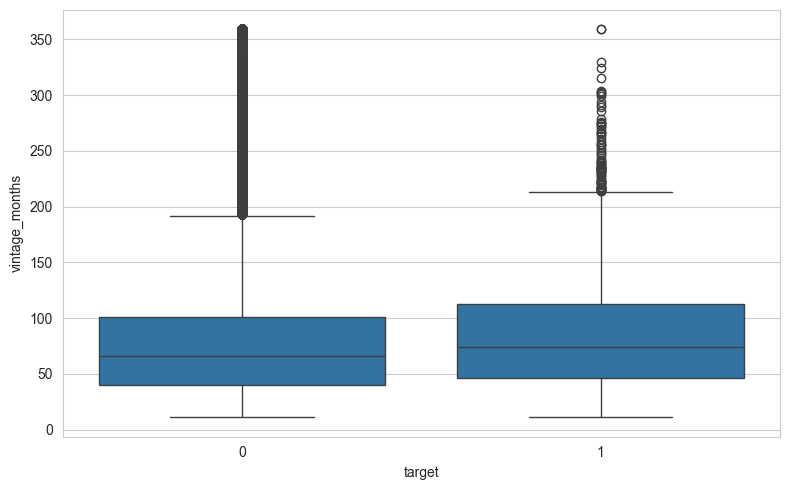

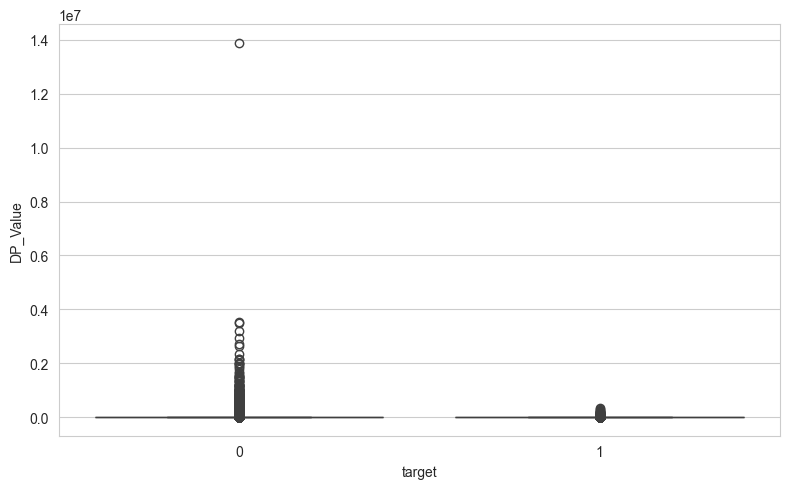

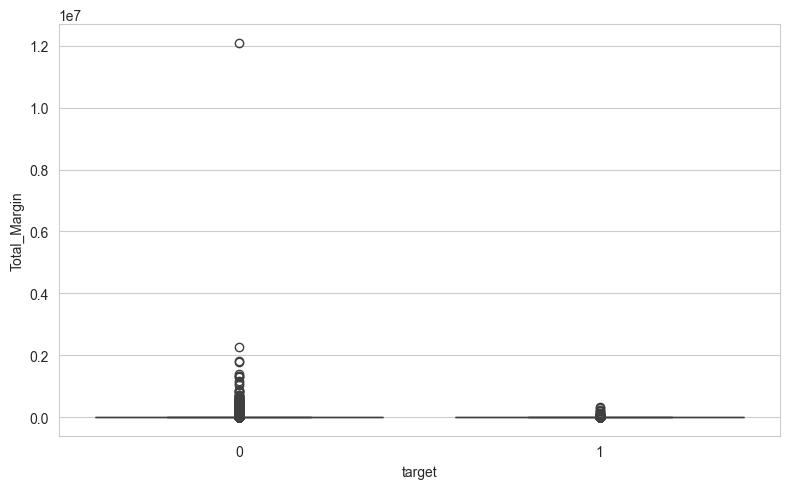

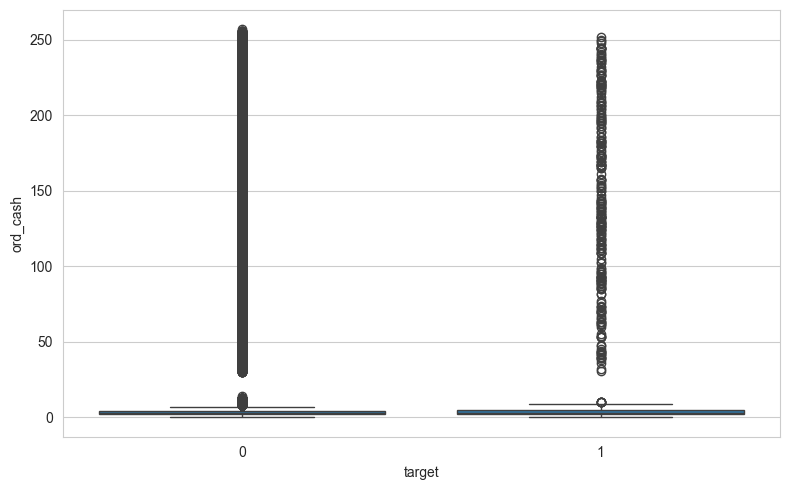

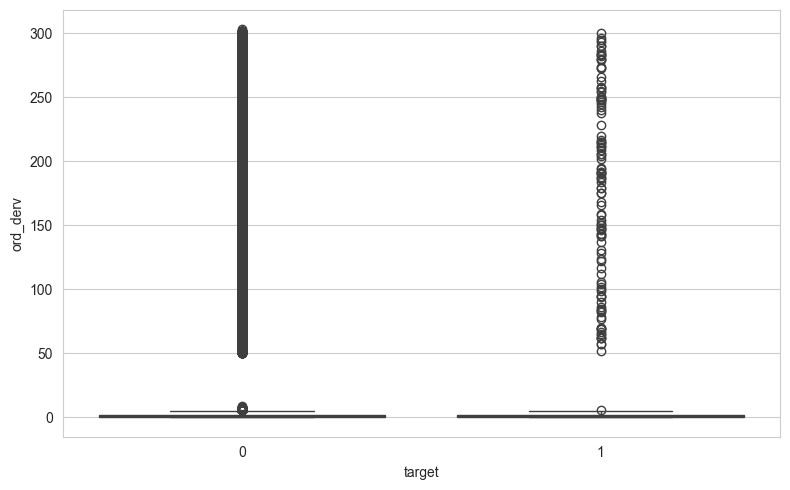

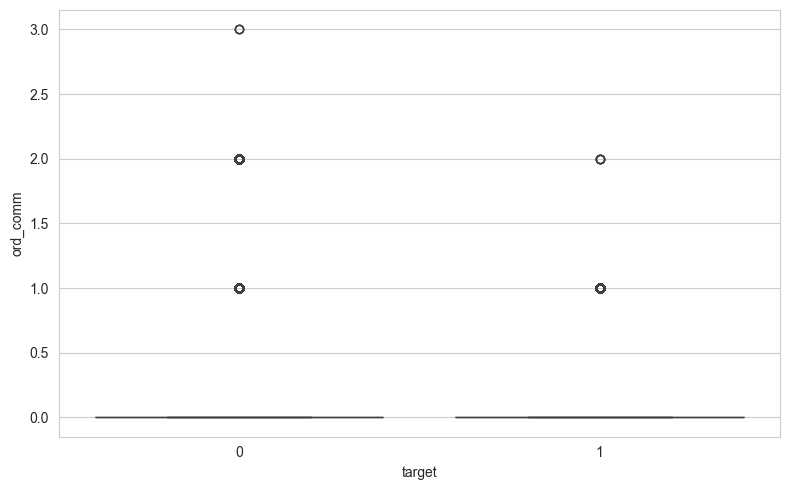

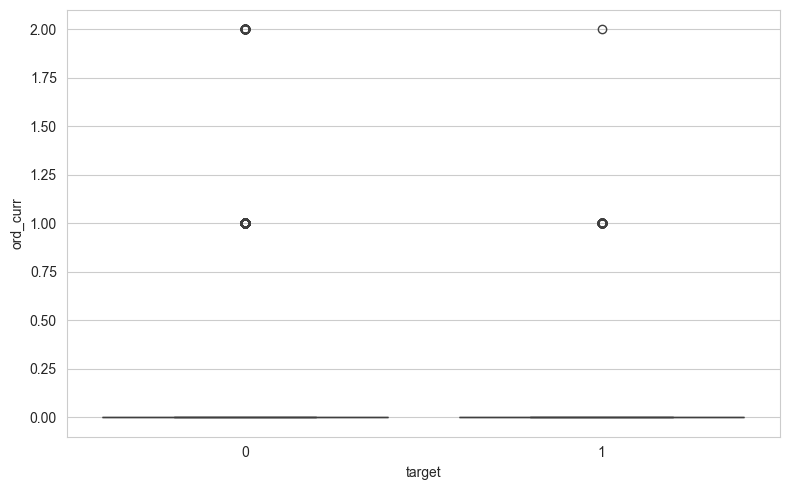

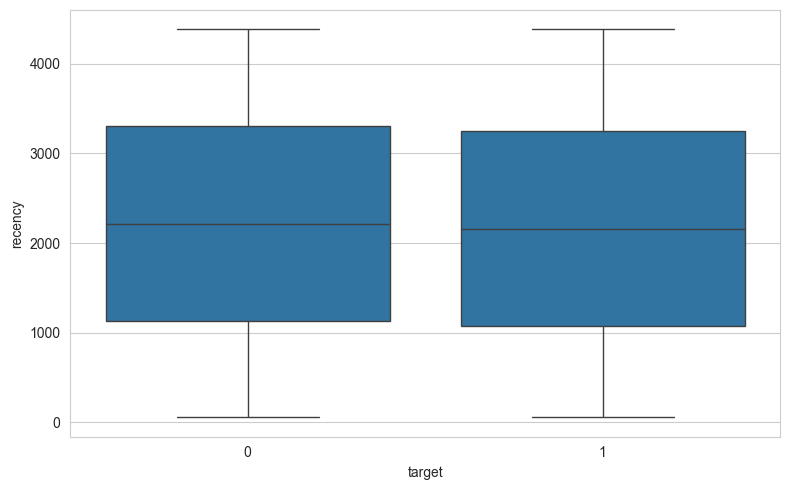

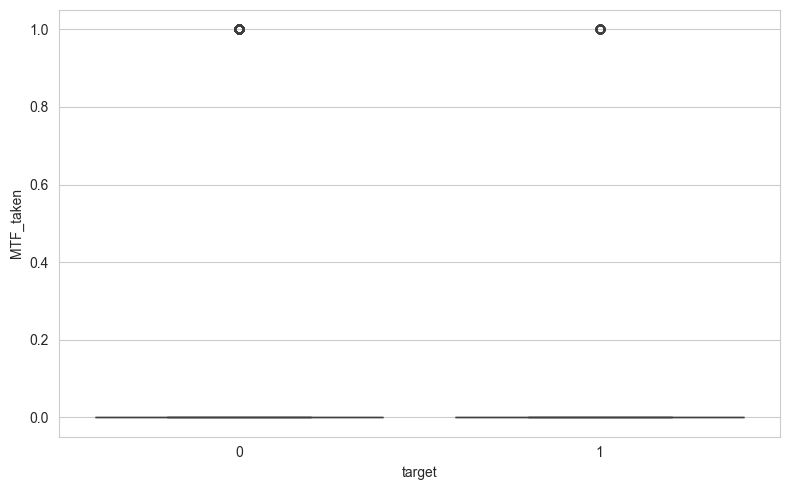

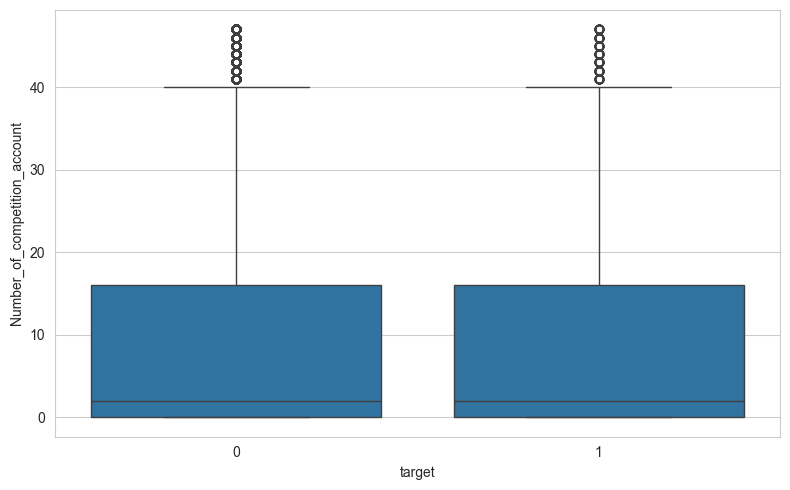

In [119]:
# ----------------------------------------------------------
# Feature vs Target
# ----------------------------------------------------------

for feature in [

    "current_age",
    "entry_age",
    "vintage_months",
    "DP_Value",
    "Total_Margin",
    "ord_cash",
    "ord_derv",
    "ord_comm",
    "ord_curr",
    "recency",
    "MTF_taken",
    "Number_of_competition_account"

]:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="target",
        y=feature
    )

    plt.tight_layout()

    plt.show()

    plt.savefig(f"{FIGURE_PATH}/{feature}_vs_target.png")

    plt.close()

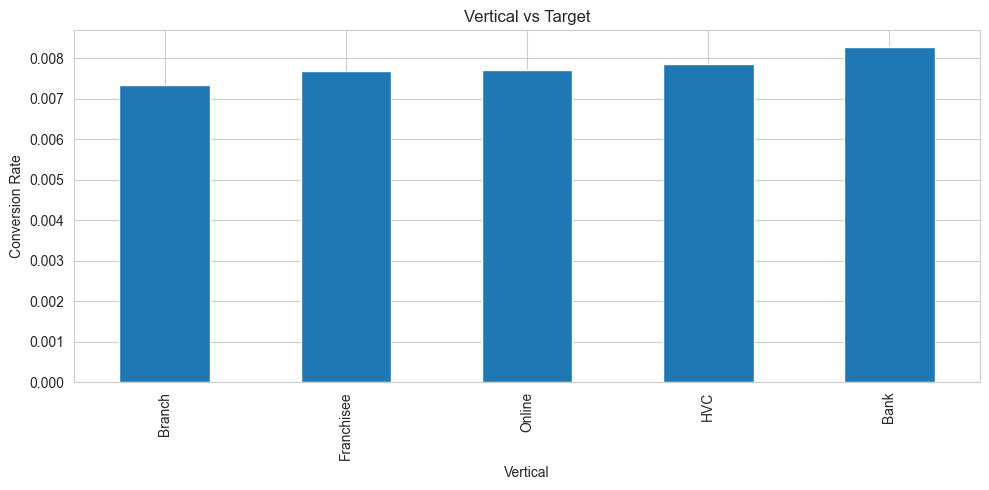

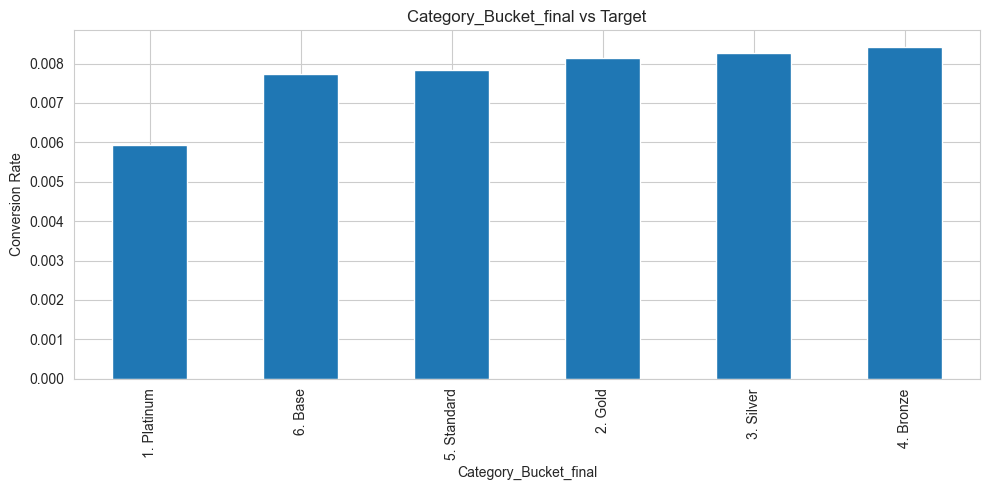

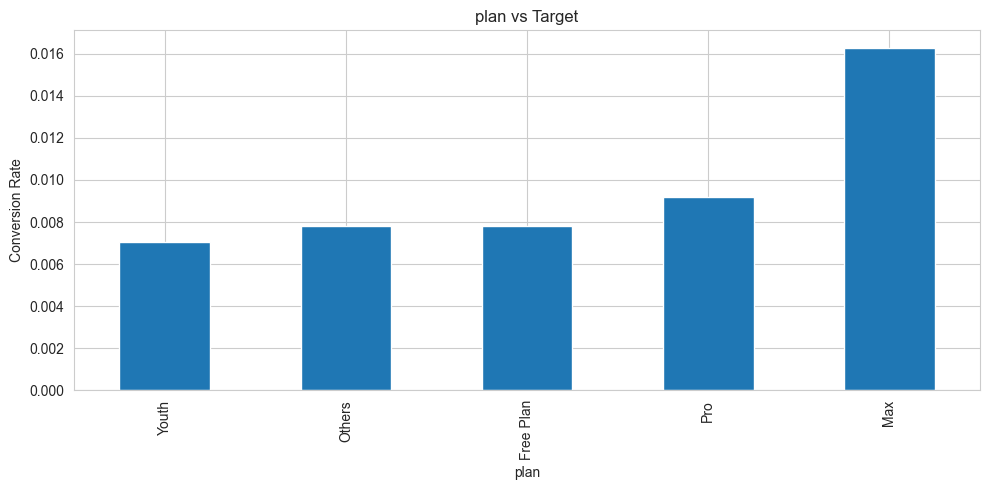

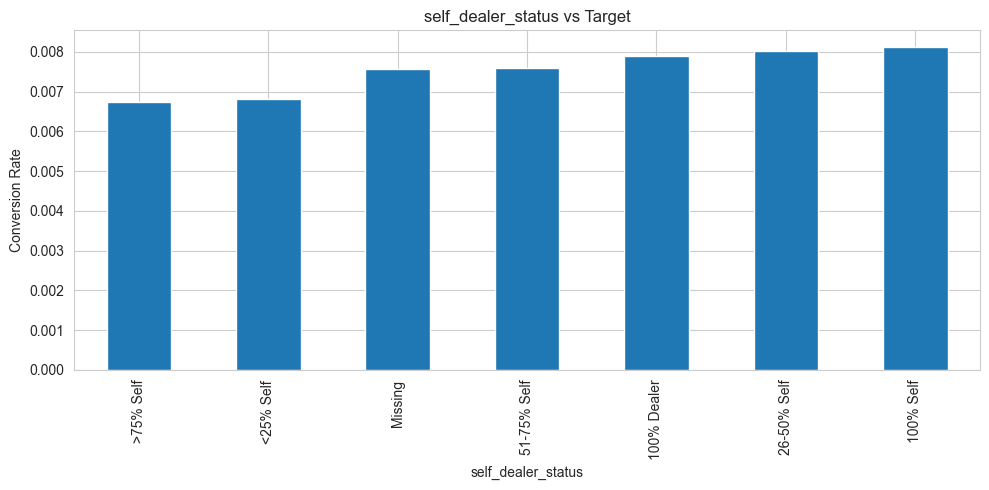

In [120]:
# ----------------------------------------------------------
# Categorical Target Rates
# ----------------------------------------------------------

for feature in [

    "Vertical",
    "Category_Bucket_final",
    "plan",
    "self_dealer_status"

]:

    plt.figure(figsize=(10,5))

    rate = (

        df
        .groupby(feature)["target"]
        .mean()
        .sort_values()

    )

    rate.plot(kind="bar")

    plt.ylabel("Conversion Rate")

    plt.title(f"{feature} vs Target")

    plt.tight_layout()

    plt.show()

    plt.savefig(f"{FIGURE_PATH}/{feature}_conversion.png")

    plt.close()

In [121]:
# ----------------------------------------------------------
# Class Imbalance
# ----------------------------------------------------------

positive_rate = df["target"].mean()

print("=" * 70)
print("Target Rate")
print("=" * 70)

print(f"{positive_rate:.2%}")

Target Rate
0.77%


In [122]:
# ----------------------------------------------------------
# Save Dataset
# ----------------------------------------------------------

df.to_csv(OUTPUT_DATA, index=False)

print("=" * 70)
print("EDA Completed Successfully")
print("=" * 70)

print(f"Processed data saved to : {OUTPUT_DATA}")
print(f"Figures saved to        : {FIGURE_PATH}")

EDA Completed Successfully
Processed data saved to : e:\github\AB Testing\outputs\eda_dataset.csv
Figures saved to        : outputs
